## Imports

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sps
from IPython.display import display, Latex, Markdown

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

## Data Exploration

### Read Dataset

In [107]:
df = pd.read_csv('generative_ai_misinformation_dataset.csv')

### Dataframe Shape

In [108]:
df.shape

(500, 31)

### Dataframe Analysis

In [109]:
df.head()

,id,post_id,platform,timestamp,date,time,month,weekday,country,city,...,sentiment_score,toxicity_score,model_signature,detected_synthetic_score,embedding_sim_to_facts,factcheck_verdict,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
0,1,P0001,Reddit,2024-03-06 10:01:00,2024-03-06,10:01:00,March,Wednesday,USA,New York,...,-0.223,0.271,GPT-like,0.829,0.357,TRUE,4,0.543,3899,1
1,2,P0002,Reddit,2025-08-07 18:30:00,2025-08-07,18:30:00,August,Thursday,Germany,Berlin,...,-0.718,0.802,GPT-like,0.075,0.987,FALSE,3,0.199,7651,0
2,3,P0003,Telegram,2024-12-13 03:15:00,2024-12-13,03:15:00,December,Friday,USA,New York,...,-0.989,0.815,GPT-like,0.707,0.729,PARTLY,0,0.074,7260,0
3,4,P0004,Twitter,2024-04-05 07:10:00,2024-04-05,07:10:00,April,Friday,USA,Chicago,...,-0.283,0.116,human,0.863,0.623,FALSE,2,0.064,7454,1
4,5,P0005,Telegram,2024-06-07 06:18:00,2024-06-07,06:18:00,June,Friday,Germany,Hamburg,...,-0.378,0.325,GPT-like,0.730,0.638,PARTLY,0,0.472,8320,0


There are 500 samples with 30 columns and 1 target label ```is_misinformation```. Some columns are not really features, for example the two ID columns. The timestamp of the post is included, and so are some derived columns like ```date```, ```time```, ```month```, and ```weekday```. There are columms containing information about the post author and a substantial number of columns about the post content. There are some raw features like ```text_length```, ```num_urls```, etc. However, there are also a fair few processed features such as ```readability_score```, ```sentiment_score```, etc.

Numerical variables: ```author_followers```, ```text_length```, ```token_count```, ```readability_score```, ```num_urls```, ```num_mentions```, ```num_hashtags```, ```sentiment_score```, ```toxicity_score```, ```detected_synthetic_score```, ```embedding_sim_to_facts```, ```external_factchecks_count```, ```source_domain_reliability```, ```engagement```

Categorical variables: ```platform```, ```month```, ```weekday```, ```country```, ```city```, ```timezone```, ```author_verified```, ```model_signature```, ```factcheck_verdict```, ```is_misinformation```

Other variables: ```id```, ```post_id```, ```timestamp```, ```date```, ```time```, ```author_id```, ```text```

### Class Counts

In [110]:
df['is_misinformation'].value_counts()

is_misinformation
1    268
0    232
Name: count, dtype: int64

### Missing Value Counts

In [111]:
df.isna().sum().rename('Missing Value Count')

id                           0
post_id                      0
platform                     0
timestamp                    0
date                         0
time                         0
month                        0
weekday                      0
country                      0
city                         0
timezone                     0
author_id                    0
author_followers             0
author_verified              0
text                         0
text_length                  0
token_count                  0
readability_score            0
num_urls                     0
num_mentions                 0
num_hashtags                 0
sentiment_score              0
toxicity_score               0
model_signature              0
detected_synthetic_score     0
embedding_sim_to_facts       0
factcheck_verdict            0
external_factchecks_count    0
source_domain_reliability    0
engagement                   0
is_misinformation            0
Name: Missing Value Count, dtype: int64

### Histograms

array([[<Axes: title={'center': 'author_followers'}>,
        <Axes: title={'center': 'text_length'}>,
        <Axes: title={'center': 'token_count'}>,
        <Axes: title={'center': 'readability_score'}>],
       [<Axes: title={'center': 'num_urls'}>,
        <Axes: title={'center': 'num_mentions'}>,
        <Axes: title={'center': 'num_hashtags'}>,
        <Axes: title={'center': 'sentiment_score'}>],
       [<Axes: title={'center': 'toxicity_score'}>,
        <Axes: title={'center': 'detected_synthetic_score'}>,
        <Axes: title={'center': 'embedding_sim_to_facts'}>,
        <Axes: title={'center': 'external_factchecks_count'}>],
       [<Axes: title={'center': 'source_domain_reliability'}>,
        <Axes: title={'center': 'engagement'}>, <Axes: >, <Axes: >]],
      dtype=object)

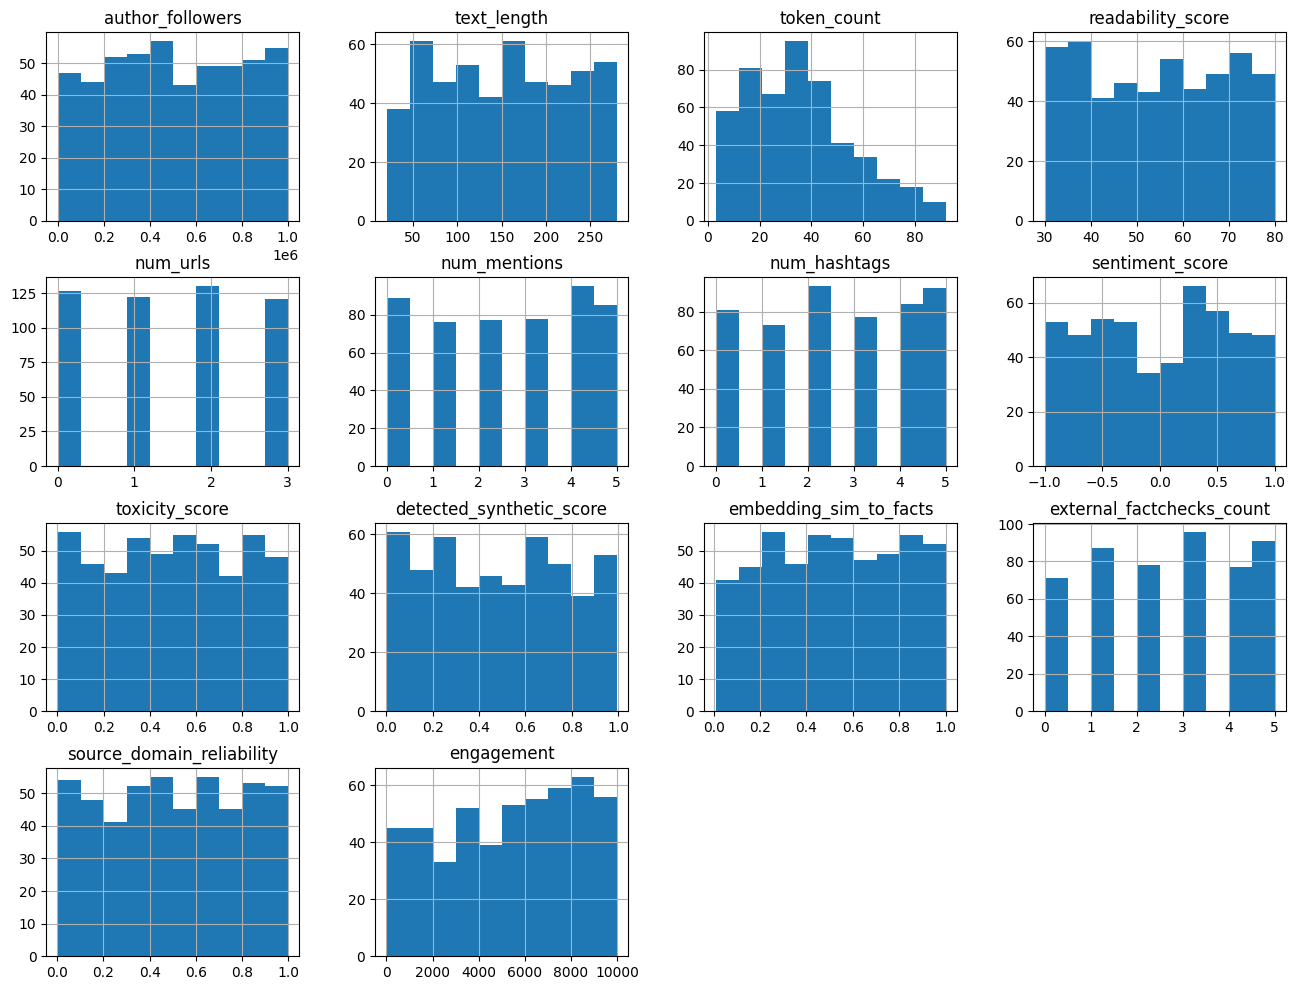

In [112]:
numeric_cols = ['author_followers', 'text_length', 'token_count', 'readability_score', 'num_urls', 'num_mentions', 'num_hashtags', 'sentiment_score', 'toxicity_score', 'detected_synthetic_score', 'embedding_sim_to_facts', 'external_factchecks_count', 'source_domain_reliability', 'engagement']
df[numeric_cols].hist(figsize = (16, 12))

## Feature Learning

### Get Year, Day of Month, Hour From Timestamp

In [113]:
df_processed = df
df_processed['timestamp'] = pd.to_datetime(df['timestamp'])
df_processed['year'] = df_processed['timestamp'].dt.year
df_processed['day_of_month'] = df_processed['timestamp'].dt.day
df_processed['hour'] = df_processed['timestamp'].dt.hour
df_processed[['year', 'day_of_month', 'hour']].head()

,year,day_of_month,hour
0,2024,6,10
1,2025,7,18
2,2024,13,3
3,2024,5,7
4,2024,7,6


## Pre-processing

### Remove Unneeded Columns

In [114]:
df_processed = df_processed.drop(['id', 'post_id', 'timestamp', 'date', 'time', 'author_id', 'text'], axis = 1)

### One-hot Encoding

In [115]:
text_cols = ['platform', 'month', 'weekday', 'country', 'city', 'timezone', 'model_signature', 'factcheck_verdict'] # maybe factcheck verdict should be label encoded
df_processed = pd.get_dummies(df_processed, columns = text_cols, dtype = np.int64)
df_processed.head()

,author_followers,author_verified,text_length,token_count,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,...,timezone_EST,timezone_GMT,timezone_IST,model_signature_GPT-like,model_signature_human,model_signature_unknown,factcheck_verdict_FALSE,factcheck_verdict_PARTLY,factcheck_verdict_TRUE,factcheck_verdict_UNVERIFIED
0,74491,0,137,34,44.05,1,0,0,-0.223,0.271,...,1,0,0,1,0,0,0,0,1,0
1,199709,0,144,24,68.61,0,5,3,-0.718,0.802,...,0,0,0,1,0,0,1,0,0,0
2,470455,0,118,29,68.56,3,1,2,-0.989,0.815,...,1,0,0,1,0,0,0,1,0,0
3,224180,1,228,38,46.54,0,1,3,-0.283,0.116,...,1,0,0,0,1,0,1,0,0,0
4,63968,1,131,43,74.36,0,0,4,-0.378,0.325,...,0,0,0,1,0,0,0,1,0,0


### Correlation Heatmap Across Features

<Axes: >

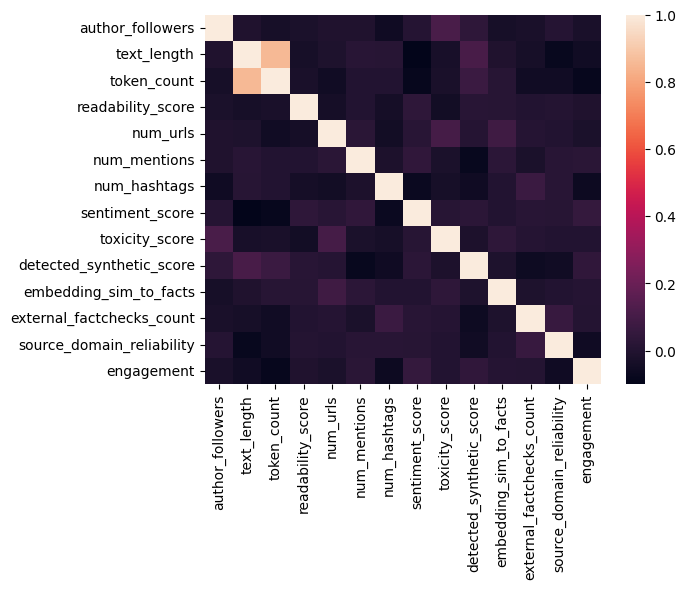

In [116]:
sns.heatmap(df_processed[numeric_cols].corr())

### Remove Columns with High Correlation

In [117]:
df_processed.drop('token_count', axis = 1)

,author_followers,author_verified,text_length,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,detected_synthetic_score,...,timezone_EST,timezone_GMT,timezone_IST,model_signature_GPT-like,model_signature_human,model_signature_unknown,factcheck_verdict_FALSE,factcheck_verdict_PARTLY,factcheck_verdict_TRUE,factcheck_verdict_UNVERIFIED
0,74491,0,137,44.05,1,0,0,-0.223,0.271,0.829,...,1,0,0,1,0,0,0,0,1,0
1,199709,0,144,68.61,0,5,3,-0.718,0.802,0.075,...,0,0,0,1,0,0,1,0,0,0
2,470455,0,118,68.56,3,1,2,-0.989,0.815,0.707,...,1,0,0,1,0,0,0,1,0,0
3,224180,1,228,46.54,0,1,3,-0.283,0.116,0.863,...,1,0,0,0,1,0,1,0,0,0
4,63968,1,131,74.36,0,0,4,-0.378,0.325,0.730,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,224214,0,239,43.89,2,2,1,-0.602,0.418,0.751,...,0,1,0,0,1,0,1,0,0,0
496,70651,0,162,38.97,3,2,4,-0.136,0.980,0.068,...,0,0,0,1,0,0,0,0,1,0
497,666266,1,88,51.14,3,0,2,-0.773,0.404,0.738,...,0,1,0,0,1,0,1,0,0,0
498,773808,1,83,43.43,1,4,0,-0.205,0.264,0.205,...,0,0,0,0,1,0,0,1,0,0


## Model 1: Support Vector Machine (SVM)

In [121]:
X = df_processed.drop('is_misinformation', axis = 1)
y = df_processed['is_misinformation']

svm = SVC(random_state = 42)

steps = []
steps.append(('standardization', StandardScaler()))
steps.append(('model', svm))
pipeline = Pipeline(steps = steps)

cross_val = StratifiedKFold(n_splits = 5)
scores = cross_val_score(pipeline, X, y, scoring = 'accuracy', cv = cross_val)
print(f'Accuracy: {np.mean(scores)}')

Accuracy: 0.48600000000000004


## Model 2: Uniform Naive Bayes? (Lolll)

## Bibliography

- https://machinelearningmastery.com/data-preparation-without-data-leakage/
- https://medium.com/data-science/machine-learning-with-datetime-feature-engineering-predicting-healthcare-appointment-no-shows-5e4ca3a85f96